## Setup & Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
import numpy as np

In [4]:
# styling for plots
sns.set_theme(style="whitegrid", palette="muted")

In [5]:
print("Loading dataset from HuggingFace...")
dataset = load_dataset("bitext/Bitext-customer-support-llm-chatbot-training-dataset", split="train")
df = pd.DataFrame(dataset)
print(f"Dataset Shape: {df.shape}")
display(df.head(3))

Loading dataset from HuggingFace...


README.md:   0%|          | 0.00/11.9k [00:00<?, ?B/s]

c:\Users\lenovo\AI_Portfolio\customer_support_copilot\venv\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\lenovo\.cache\huggingface\hub\datasets--bitext--Bitext-customer-support-llm-chatbot-training-dataset. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Bitext_Sample_Customer_Support_Training_(…): reconstructing file:   0%|          |  0.00B / 19.2MB            

Bitext_Sample_Customer_Support_Training_(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/26872 [00:00<?, ? examples/s]

Dataset Shape: (26872, 5)


,flags,instruction,category,intent,response
0,B,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...
1,BQZ,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...
2,BLQZ,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...


In [24]:
sample = df.sample(1)
for _, row in sample.iterrows():
    print(f"instruction:{row['instruction']}\n")
    print(f"category:{row['category']}\n")
    print(f"intent:{row['intent']}\n")
    print(f"response:{row['response']}")


instruction:I don't know what to do to purchase several products

category:ORDER

intent:place_order

response:I appreciate your interest in purchasing several products from us! Don't worry, I'm here to assist you every step of the way. To get started, you can visit our website and explore our wide range of products. Once you've found the items you want to purchase, simply add them to your cart and proceed to the checkout page. At the checkout, you'll need to provide your shipping address and select your preferred payment method. If you have any specific questions or need further guidance during the process, feel free to ask. Happy shopping!


In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 26872 entries, 0 to 26871
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   flags        26872 non-null  str  
 1   instruction  26872 non-null  str  
 2   category     26872 non-null  str  
 3   intent       26872 non-null  str  
 4   response     26872 non-null  str  
dtypes: str(5)
memory usage: 19.1 MB


In [27]:
df.describe()

,flags,instruction,category,intent,response
count,26872,26872,26872,26872,26872
unique,394,24635,11,27,26870
top,BL,do you ship to {{Delivery City}}?,ACCOUNT,check_invoice,"Firstly, I truly understand how pivotal the {{..."
freq,5212,8,5986,1000,2


In [33]:
df["intent"].value_counts()

intent
check_invoice               1000
complaint                   1000
contact_customer_service    1000
edit_account                1000
switch_account              1000
check_payment_methods        999
contact_human_agent          999
delivery_period              999
get_invoice                  999
newsletter_subscription      999
payment_issue                999
registration_problems        999
cancel_order                 998
place_order                  998
track_refund                 998
change_order                 997
check_refund_policy          997
create_account               997
get_refund                   997
review                       997
set_up_shipping_address      997
delete_account               995
delivery_options             995
recover_password             995
track_order                  995
change_shipping_address      973
check_cancellation_fee       950
Name: count, dtype: int64

In [34]:
df["category"].value_counts()

category
ACCOUNT         5986
ORDER           3988
REFUND          2992
INVOICE         1999
CONTACT         1999
PAYMENT         1998
FEEDBACK        1997
DELIVERY        1994
SHIPPING        1970
SUBSCRIPTION     999
CANCEL           950
Name: count, dtype: int64

##  Check Missing Values


In [25]:
missing_data = df.isnull().sum()
print("\nMissing Values per Column:")
print(f"{missing_data} ")


Missing Values per Column:
flags          0
instruction    0
category       0
intent         0
response       0
dtype: int64 


## Category And Intent 

C:\Users\lenovo\AppData\Local\Temp\ipykernel_32316\2977667121.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.values, y=category_counts.index, ax=axes[0], palette="Blues_d")
C:\Users\lenovo\AppData\Local\Temp\ipykernel_32316\2977667121.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=intent_counts.values, y=intent_counts.index, ax=axes[1], palette="mako")


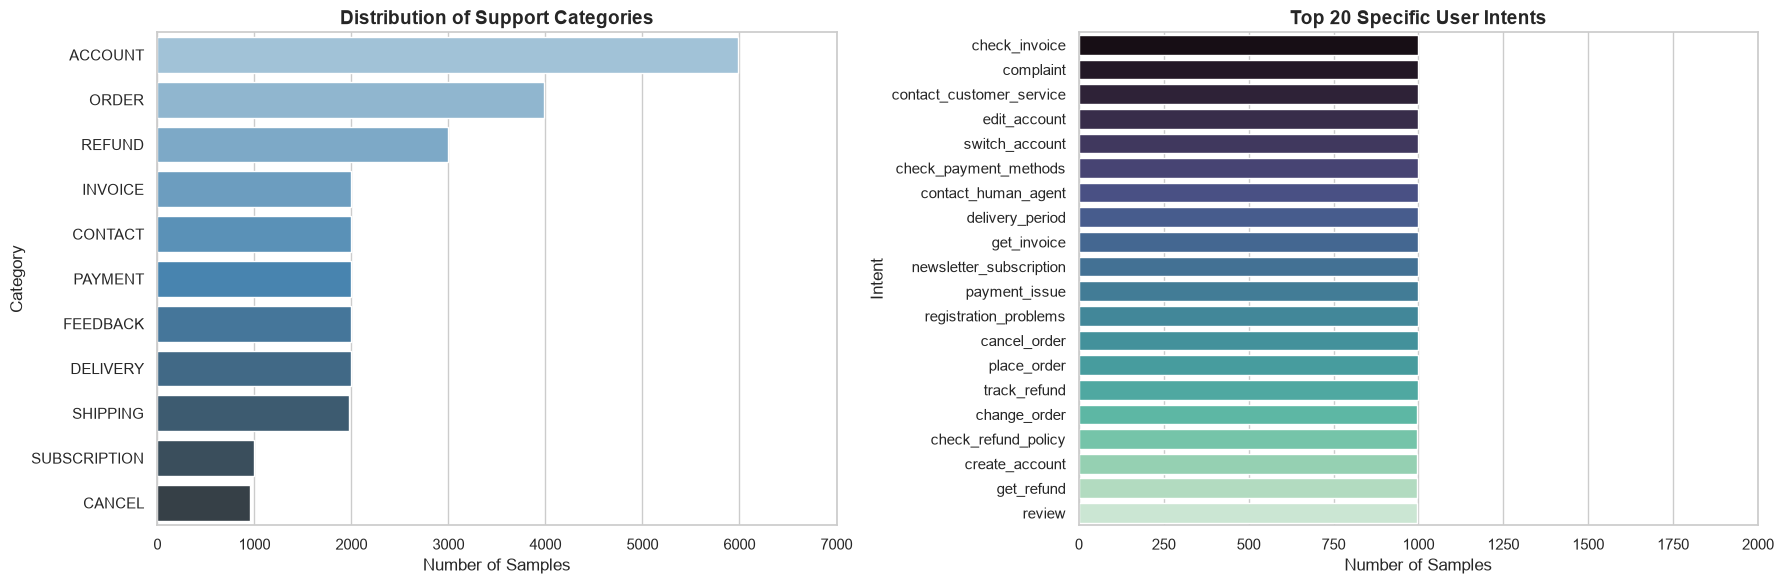

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Broad Categories
category_counts = df['category'].value_counts()
sns.barplot(x=category_counts.values, y=category_counts.index, ax=axes[0], palette="Blues_d")
axes[0].set_title("Distribution of Support Categories", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Number of Samples")
axes[0].set_ylabel("Category")
axes[0].set_xlim(0,7000)
# Top 20 Specific Intents 
intent_counts = df['intent'].value_counts().head(20) 
sns.barplot(x=intent_counts.values, y=intent_counts.index, ax=axes[1], palette="mako") 
axes[1].set_title("Top 20 Specific User Intents", fontsize=14, fontweight='bold') 
axes[1].set_xlabel("Number of Samples") 
axes[1].set_ylabel("Intent")


axes[1].set_xlim(0,2000) 


plt.tight_layout()
plt.show()


In [ ]:
print(f"Total unique categories: {df['category'].nunique()}")
print(f"Total unique intents: {df['intent'].nunique()}")

Total unique categories: 11
Total unique intents: 27


## Token Distribution

In [39]:
# Approximate tokens (1 word ≈ 1.3 sub-word tokens)
df['instruction_tokens'] = df['instruction'].apply(lambda x: len(str(x).split()) * 1.3)
df['response_tokens'] = df['response'].apply(lambda x: len(str(x).split()) * 1.3)

# The total sequence length is what goes into the model (Prompt + Context + Response)
# We add ~40 tokens to account for our ChatML system prompt framing.
df['total_sequence_tokens'] = df['instruction_tokens'] + df['response_tokens'] + 40
df[['instruction_tokens','response_tokens','total_sequence_tokens']].describe()

,instruction_tokens,response_tokens,total_sequence_tokens
count,26872.000000,26872.000000,26872.000000
mean,11.298273,136.225748,187.524021
std,3.386506,68.856065,69.421581
min,1.300000,11.700000,60.800000
25%,9.100000,93.600000,144.000000
50%,11.700000,117.000000,168.700000
75%,14.300000,161.200000,212.900000
max,20.800000,522.600000,576.900000


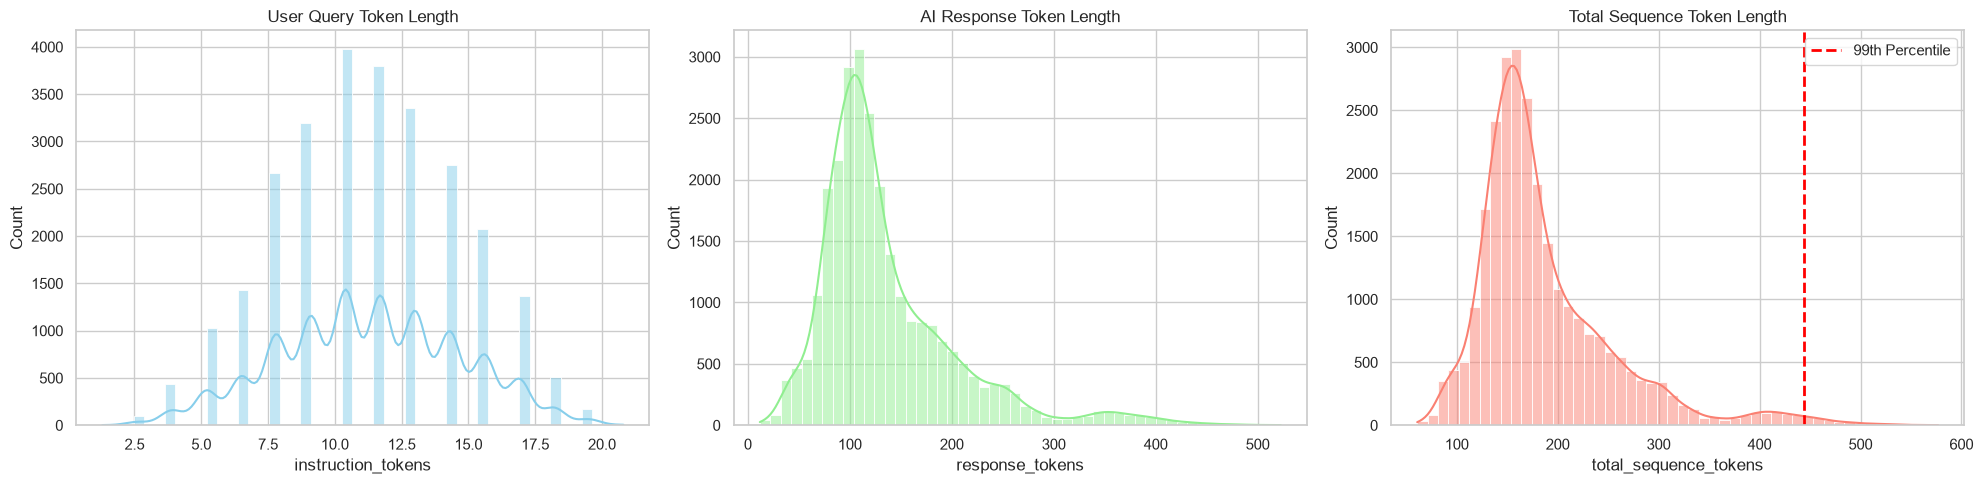

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.histplot(df['instruction_tokens'], bins=50, ax=axes[0], color='skyblue', kde=True)
axes[0].set_title("User Query Token Length")

sns.histplot(df['response_tokens'], bins=50, ax=axes[1], color='lightgreen', kde=True)
axes[1].set_title("AI Response Token Length")

sns.histplot(df['total_sequence_tokens'], bins=50, ax=axes[2], color='salmon', kde=True)
axes[2].set_title("Total Sequence Token Length")
axes[2].axvline(df['total_sequence_tokens'].quantile(0.99), color='red', linestyle='dashed', linewidth=2, label='99th Percentile')
axes[2].legend()

plt.tight_layout()
plt.show()


In [41]:
p99_length = int(df['total_sequence_tokens'].quantile(0.99))
max_length = int(df['total_sequence_tokens'].max())

print(f"Average Total Tokens per sample: {int(df['total_sequence_tokens'].mean())}")
print(f"99% of all data falls under {p99_length} tokens.")
print(f"Absolute longest sequence is {max_length} tokens.")

Average Total Tokens per sample: 187
99% of all data falls under 444 tokens.
Absolute longest sequence is 576 tokens.
